In [ ]:
#!pip install matplotlib

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
#from airsenal.scripts.replay_season import rerun_predictions
from airsenal.framework.prediction_utils import get_player_scores
from airsenal.framework.schema import Fixture, PlayerScore, Player, PlayerPrediction

/home/mnegm/anaconda3/envs/airsenalenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker

# 1. Define the absolute path to the database
DB_PATH = "sqlite:////home/mnegm/.local/share/airsenal/data.db"

# 2. Create the engine and session factory
engine = create_engine(DB_PATH)
Session = sessionmaker(bind=engine)

# 3. Create a session
session = Session()

In [3]:
print(session.bind)

Engine(sqlite:////home/mnegm/.local/share/airsenal/data.db)


## Generate Predictions (slow!)

In [4]:
season = "2425"
gw_start = 1
gw_end = 33
weeks_ahead = 1 
# num_thread = 1

Run outside this notebook:
```
rerun_predictions(
    season=season,
    gw_start=gw_start,
    gw_end=gw_end,
    weeks_ahead=weeks_ahead, 
    num_thread=num_thread,
)
```

## Get Players from Database

In [5]:
# Fetch all players (not just Arsenal)
all_players = pd.read_sql(session.query(Player).statement, session.bind)
all_players.set_index("player_id", inplace=True)
all_players = all_players["name"]
all_players

player_id
1              Fábio Ferreira Vieira
2          Gabriel Fernando de Jesus
3       Gabriel dos Santos Magalhães
4                        Kai Havertz
5                          Karl Hein
                    ...             
1601               Christian Marques
1602                   Louie Moulden
1603                    James Storer
1604       Bruno André Cavaco Jordão
1605                  Dion Sanderson
Name: name, Length: 1605, dtype: object

## Get Predictions from the Database

In [6]:
preds = pd.read_sql(session.query(PlayerPrediction).statement, session.bind)

tags = preds["tag"].unique().astype(str)
tags

array(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23',
       '24', '25', '26', '27', '28', '29', '30', '31', '32', '33'],
      dtype='<U2')

In [7]:
tags

array(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23',
       '24', '25', '26', '27', '28', '29', '30', '31', '32', '33'],
      dtype='<U2')

In [8]:
fixtures = pd.read_sql(
    session.query(Fixture)
    .filter(Fixture.season == "2425")
    .statement,
    session.bind
)
print(fixtures["gameweek"].unique())  # Should output [1, 2, ..., 33]

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38]


In [9]:
# Check PlayerScore entries for a specific fixture
example_fixture_id = 285  # Replace with a valid fixture_id
player_scores = pd.read_sql(
    session.query(PlayerScore)
    .filter(PlayerScore.fixture_id == example_fixture_id)
    .statement,
    session.bind
)
print(player_scores)

       id player_team opponent  points  goals  assists  bonus  conceded  \
0   18702         SOU      WOL       1      0        0      0         2   
1   18735         SOU      WOL       1      0        0      0         0   
2   18768         SOU      WOL       2      0        0      0         2   
3   18801         SOU      WOL       0      0        0      0         0   
4   18834         SOU      WOL       0      0        0      0         0   
..    ...         ...      ...     ...    ...      ...    ...       ...   
82  23641         WOL      SOU       2      0        0      0         1   
83  23652         WOL      SOU       8      0        0      0         0   
84  23661         WOL      SOU       1      0        0      0         0   
85  23670         WOL      SOU       3      0        0      0         0   
86  23677         WOL      SOU       0      0        0      0         0   

    minutes  player_id  ...  saves  bps  influence  creativity  threat  \
0        90        631  .

## Get Actual Scores from the Database

In [10]:
# Fetch actual scores with corrected join on Fixture.fixture_id
query = (
    session.query(
        PlayerScore.player_id,
        PlayerScore.fixture_id,
        PlayerScore.points,
        Fixture.gameweek,
        Fixture.season
    )
    .join(Fixture, PlayerScore.fixture_id == Fixture.fixture_id)
    .filter(Fixture.season == season)
    .filter(Fixture.gameweek >= gw_start)
    .filter(Fixture.gameweek <= gw_end)
)

scores = pd.read_sql(query.statement, session.bind)

scores = scores.merge(
    all_players.reset_index(),  # Reset index to make "player_id" a column
    on="player_id"
)

scores

,player_id,fixture_id,points,gameweek,season,name
0,1,3,0,1,2425,Fábio Ferreira Vieira
1,1,17,0,2,2425,Fábio Ferreira Vieira
2,1,21,0,3,2425,Fábio Ferreira Vieira
3,1,39,0,4,2425,Fábio Ferreira Vieira
4,1,50,0,5,2425,Fábio Ferreira Vieira
...,...,...,...,...,...,...
23676,799,285,0,29,2425,Mateus Mané
23677,799,291,0,30,2425,Mateus Mané
23678,799,302,0,31,2425,Mateus Mané
23679,799,317,0,32,2425,Mateus Mané


In [11]:
# Ensure the 'tag' column in preds and 'gameweek' column in scores have the same data type
preds["tag"] = preds["tag"].astype(int)  # Convert 'tag' to int

# Merge predictions and actual points
merged = pd.merge(
    preds[["player_id", "tag", "predicted_points"]],  # Prediction columns
    scores[["player_id", "gameweek", "points"]],       # Actual points
    left_on=["player_id", "tag"],                      # Match player + gameweek
    right_on=["player_id", "gameweek"],
    how="left",                                        # Keep all predictions
    suffixes=("_pred", "_actual")
)

# Rename columns for clarity
merged.rename(columns={"gameweek": "tag"}, inplace=True)

merged

,player_id,tag,predicted_points,tag,points
0,490,1,5.654568,1,7
1,461,1,7.269857,1,14
2,242,1,4.681201,1,2
3,14,1,5.234641,1,12
4,698,1,5.883903,1,2
...,...,...,...,...,...
24110,310,33,0.000000,33,-1
24111,369,33,1.315638,33,0
24112,381,33,1.405707,33,0
24113,413,33,1.076510,33,2


In [ ]:
# Calculate errors
merged["error"] = merged["predicted_points"] - merged["points"]
merged["absolute_error"] = merged["error"].abs()

# Check for missing actual points (if any)
missing_actuals = merged[merged["points"].isnull()]
print(f"Missing actual points for {len(missing_actuals)} predictions.")


Missing actual points for 0 predictions.


In [13]:
# MAE and RMSE
mae = merged["absolute_error"].mean()
rmse = np.sqrt((merged["error"] ** 2).mean())

print(f"MAE: {mae:.2f}")    # Average absolute error
print(f"RMSE: {rmse:.2f}")  # Penalizes larger errors

MAE: 1.02
RMSE: 1.97


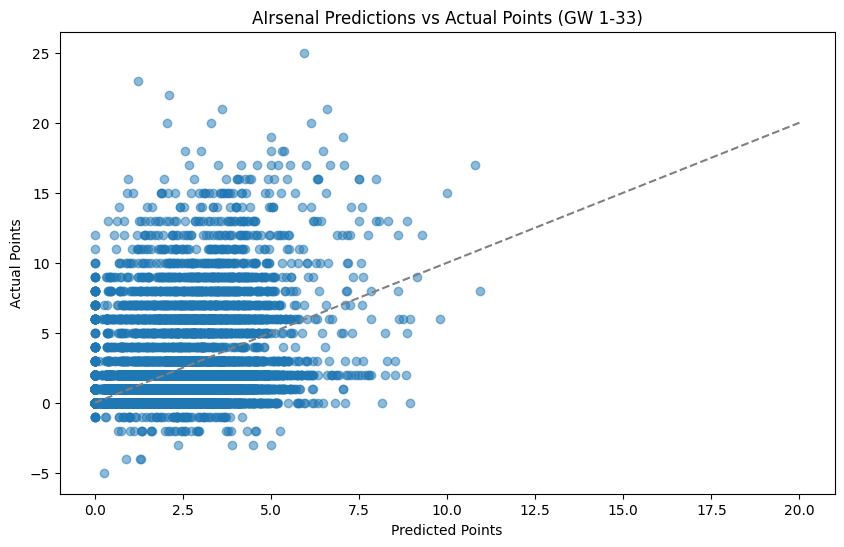

In [14]:
# Plotting the predictions vs actual points
plt.figure(figsize=(10, 6))
plt.scatter(merged["predicted_points"], merged["points"], alpha=0.5)
plt.plot([0, 20], [0, 20], "--", c="gray")  # Perfect prediction line
plt.xlabel("Predicted Points")
plt.ylabel("Actual Points")
plt.title("AIrsenal Predictions vs Actual Points (GW 1-33)")
plt.show()

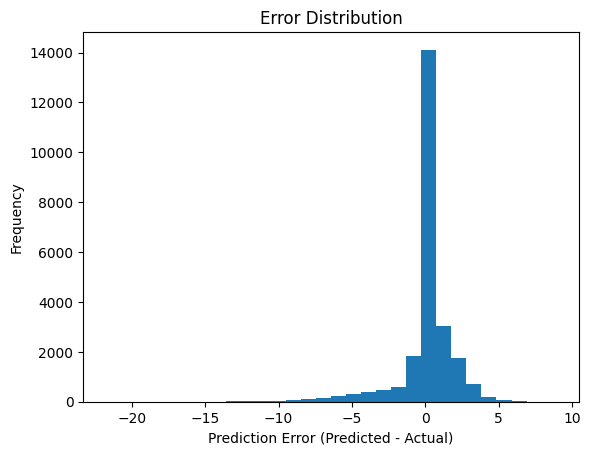

In [75]:
plt.hist(merged["error"], bins=30)
plt.xlabel("Prediction Error (Predicted - Actual)")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.show()

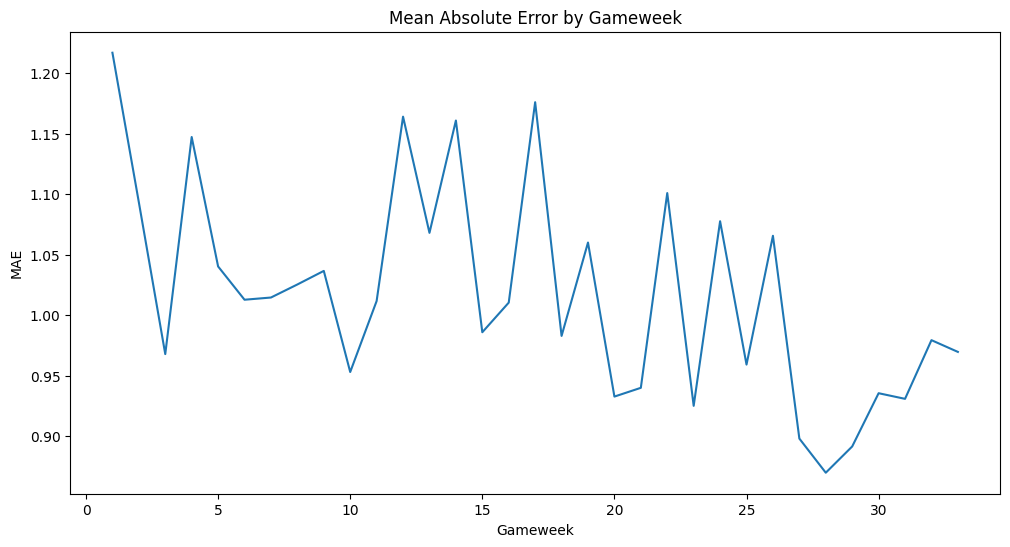

In [76]:
# Drop duplicate 'tag' column if it exists
if "tag" in merged.columns and merged.columns.tolist().count("tag") > 1:
    merged = merged.loc[:, ~merged.columns.duplicated()]

# Calculate MAE and RMSE per gameweek
gw_performance = merged.groupby("tag").agg(
    mean_error=("error", "mean"),
    mae=("absolute_error", "mean"),
    rmse=("error", lambda x: np.sqrt(np.mean(x ** 2)))
)

# Plot MAE across gameweeks
gw_performance["mae"].plot(kind="line", figsize=(12, 6))
plt.xlabel("Gameweek")
plt.ylabel("MAE")
plt.title("Mean Absolute Error by Gameweek")
plt.show()

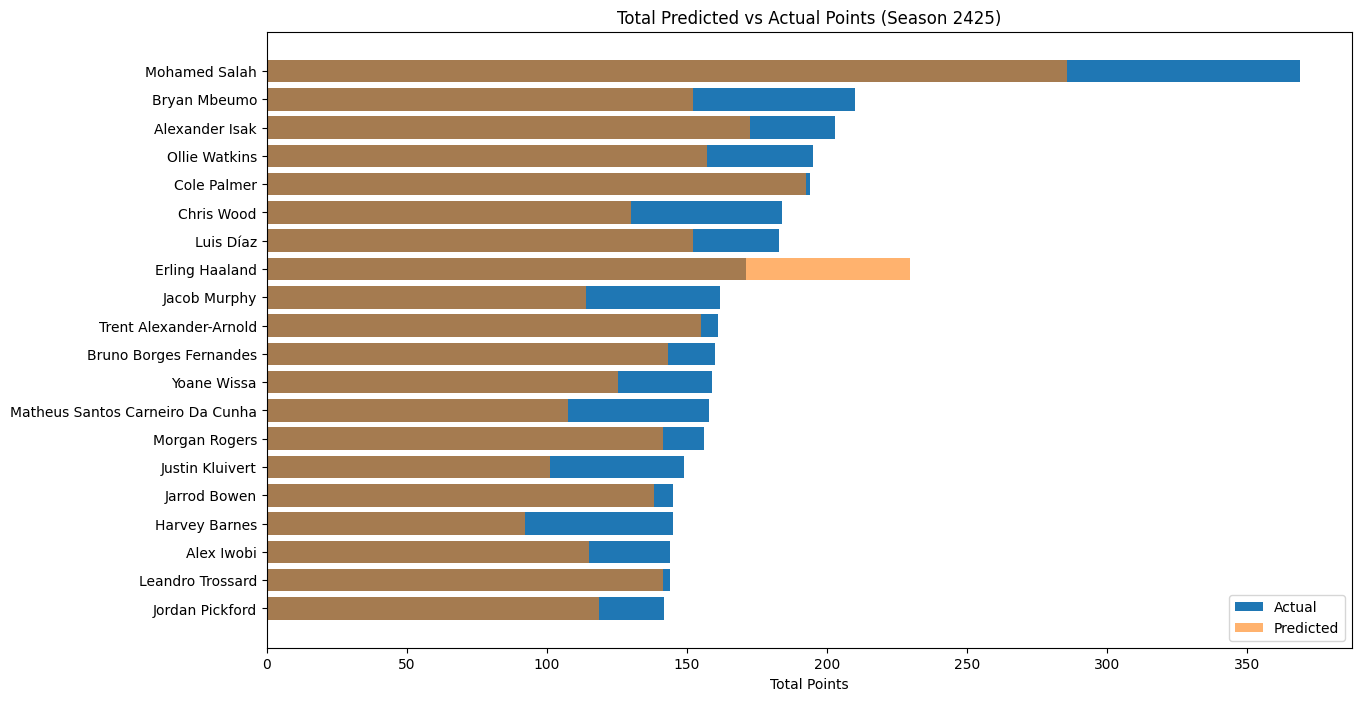

In [77]:
# Add player names to the merged DataFrame
merged = merged.merge(all_players.reset_index(), on="player_id")

# Total predicted vs actual points per player
total_points = merged.groupby("name").agg(
    total_predicted=("predicted_points", "sum"),
    total_actual=("points", "sum")
).reset_index()

# Sort by actual points
total_points = total_points.sort_values("total_actual", ascending=False)

# Plot top 20 players
top_players = total_points.head(20)
plt.figure(figsize=(14, 8))
plt.barh(top_players["name"], top_players["total_actual"], label="Actual")
plt.barh(top_players["name"], top_players["total_predicted"], alpha=0.6, label="Predicted")
plt.xlabel("Total Points")
plt.title("Total Predicted vs Actual Points (Season 2425)")
plt.legend()
plt.gca().invert_yaxis()  # Highest points at top
plt.show()

<Axes: title={'center': 'MAE and RMSE by Gameweek'}, xlabel='tag'>

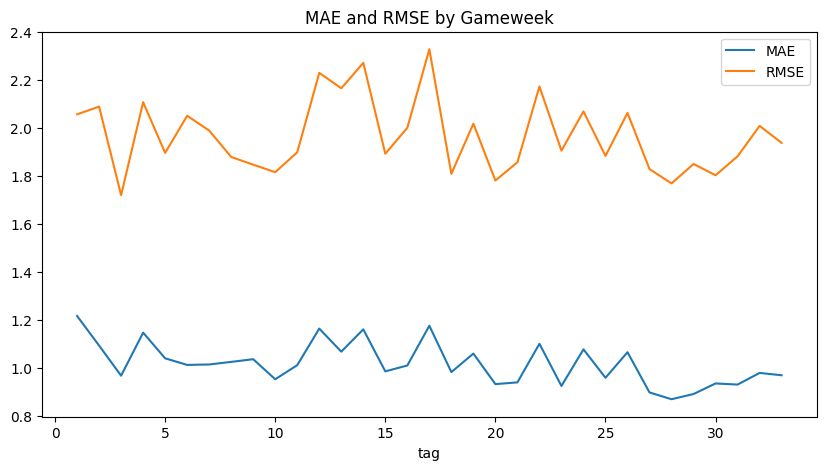

In [78]:
# Trend over time 
by_gw = merged.groupby("tag").agg({
    "absolute_error": "mean",
    "error": lambda x: np.sqrt((x**2).mean())  # RMSE
}).rename(columns={"absolute_error": "MAE", "error": "RMSE"})

by_gw.plot(title="MAE and RMSE by Gameweek", figsize=(10,5))

In [21]:
merged["player_name"] = merged["player_id"].map(all_players)
merged.sort_values("absolute_error", ascending=False).head(20)


,player_id,tag,predicted_points,points,error,absolute_error,name,player_name
8089,142,13,1.227089,23,-21.772911,21.772911,Kevin Schade,Kevin Schade
14282,93,22,2.114927,22,-19.885073,19.885073,Justin Kluivert,Justin Kluivert
3213,242,6,5.924328,25,-19.075672,19.075672,Cole Palmer,Cole Palmer
684,237,2,2.035847,20,-17.964153,17.964153,Noni Madueke,Noni Madueke
15100,95,23,3.622258,21,-17.377742,17.377742,Dango Ouattara,Dango Ouattara
8059,93,13,3.283797,20,-16.716203,16.716203,Justin Kluivert,Justin Kluivert
21330,687,31,2.566929,18,-15.433071,15.433071,Brennan Johnson,Brennan Johnson
10661,2,17,0.951728,16,-15.048272,15.048272,Gabriel Fernando de Jesus,Gabriel Fernando de Jesus
4023,724,7,3.026392,18,-14.973608,14.973608,Michail Antonio,Michail Antonio
10629,461,17,6.588917,21,-14.411083,14.411083,Mohamed Salah,Mohamed Salah


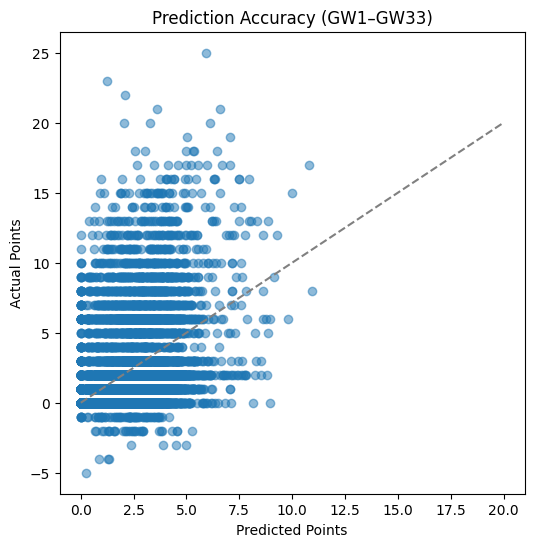

In [22]:
plt.figure(figsize=(6,6))
plt.scatter(merged["predicted_points"], merged["points"], alpha=0.5)
plt.xlabel("Predicted Points")
plt.ylabel("Actual Points")
plt.title("Prediction Accuracy (GW1–GW33)")
plt.plot([0, 20], [0, 20], linestyle="--", color="gray")  # Diagonal


In [23]:
from sklearn.metrics import r2_score
r2 = r2_score(merged["points"], merged["predicted_points"])
print(f"R² Score: {r2:.3f}")


R² Score: 0.291


/tmp/ipykernel_4919/3921388908.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prediction_success = merged.groupby('tag').apply(


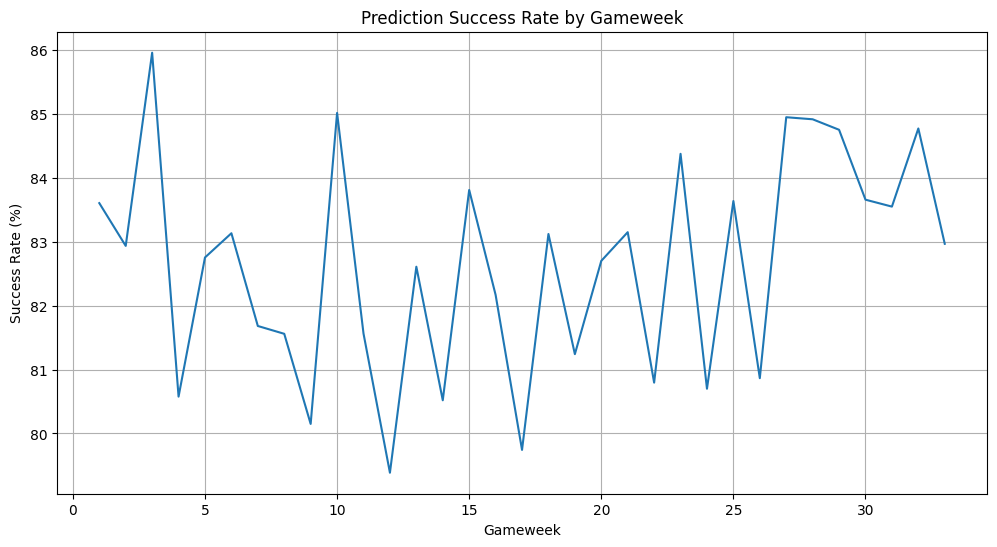

In [24]:
# Add gameweek-wise prediction success rate
prediction_success = merged.groupby('tag').apply(
    lambda x: (abs(x['error']) <= 2).mean()  # Points within 2-point margin
).reset_index()
prediction_success.columns = ['Gameweek', 'Success_Rate']

plt.figure(figsize=(12, 6))
plt.plot(prediction_success['Gameweek'], prediction_success['Success_Rate'] * 100)
plt.title('Prediction Success Rate by Gameweek')
plt.xlabel('Gameweek')
plt.ylabel('Success Rate (%)')
plt.grid(True)
plt.show()

In [25]:
# Analyze prediction accuracy by point ranges
merged['point_category'] = pd.cut(merged['points'], 
                                bins=[-1, 2, 4, 6, 8, float('inf')],
                                labels=['0-2', '3-4', '5-6', '7-8', '8+'])

category_performance = merged.groupby('point_category').agg({
    'absolute_error': ['mean', 'std'],
    'player_id': 'count'
}).round(2)

print("Performance by Point Categories:\n", category_performance)

Performance by Point Categories:
                absolute_error       player_id
                         mean   std     count
point_category                               
0-2                      0.62  0.94     21023
3-4                      1.27  1.00       880
5-6                      2.90  1.37       968
7-8                      4.59  1.48       536
8+                       7.78  2.74       598


/tmp/ipykernel_4919/3970474274.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_performance = merged.groupby('point_category').agg({


In [29]:
# Calculate prediction risk levels
merged['risk_level'] = abs(merged['error']) / merged['predicted_points']
low_risk_predictions = (merged['risk_level'] < 0.3).mean() * 100

print(f"Percentage of Low-Risk Predictions: {low_risk_predictions:.2f}%")

Percentage of Low-Risk Predictions: 9.28%


In [ ]:
import requests
import pandas as pd

def fetch_fpl_players(exclude_managers=True):
    """
    Fetch current FPL players and their details, excluding managers by default
    """
    url = "https://fantasy.premierleague.com/api/bootstrap-static/"
    
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()
        
        # Extract player data
        players_df = pd.DataFrame(data['elements'])
        
        # Select relevant columns
        players_df = players_df[['id', 'web_name', 'first_name', 'second_name', 
                               'element_type', 'team']]
        
        # Map element_type to position (excluding MNG)
        position_map = {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FWD'}
        players_df['position'] = players_df['element_type'].map(position_map)
        
        # Create full name
        players_df['full_name'] = players_df['first_name'] + ' ' + players_df['second_name']
        
        # Final columns
        fpl_players = players_df[['id', 'web_name', 'full_name', 'position', 'team']]
        
        # Remove any null positions (which would include managers)
        fpl_players = fpl_players.dropna(subset=['position'])
        
        print(f"Total FPL players fetched: {len(fpl_players)}")
        print("\nPosition distribution:")
        print(fpl_players['position'].value_counts())
        
        return fpl_players
        
    except Exception as e:
        print(f"Error fetching FPL data: {str(e)}")
        return None

# Test the updated function
fpl_players = fetch_fpl_players()
fpl_players

Total FPL players fetched: 780

Position distribution:
position
MID    346
DEF    265
FWD     87
GK      82
Name: count, dtype: int64


In [ ]:
all_players

In [ ]:
def match_exact_players(all_players_series, fpl_players_df):
    """
    Match players from database with FPL players using exact name matching
    
    Parameters:
    -----------
    all_players_series : pd.Series
        Series containing player names with player_id as index
    fpl_players_df : pd.DataFrame
        DataFrame containing FPL player information
    """
    # Convert all_players series to DataFrame with index
    db_players = all_players_series.reset_index()
    db_players.columns = ['player_id', 'name']
    
    # Prepare FPL names for matching
    fpl_names = set(fpl_players_df['full_name'].str.lower())
    
    # Find matches
    matched_players = db_players[db_players['name'].str.lower().isin(fpl_names)]
    
    # Create filtered series
    filtered_players = all_players_series[all_players_series.index.isin(matched_players['player_id'])]
    
    # Print matching statistics
    print("Matching Statistics:")
    print(f"Original players: {len(all_players_series)}")
    print(f"Matched players: {len(filtered_players)}")
    print(f"Match rate: {(len(filtered_players)/len(all_players_series))*100:.2f}%")
    
    return filtered_players

# Apply exact matching
filtered_all_players = match_exact_players(all_players, fpl_players)

# Update all_players to contain only matched players
all_players = filtered_all_players

# Display first few matched players
print("\nSample of matched players:")
print(filtered_all_players.head())
filtered_all_players

Matching Statistics:
Original players: 1605
Matched players: 780
Match rate: 48.60%

Sample of matched players:
player_id
1           Fábio Ferreira Vieira
2       Gabriel Fernando de Jesus
3    Gabriel dos Santos Magalhães
4                     Kai Havertz
5                       Karl Hein
Name: name, dtype: object


Top 10 Players by Total Points:
                        predicted_points_mean  predicted_points_sum  \
name                                                                  
Mohamed Salah                            7.72                285.64   
Bryan Mbeumo                             4.62                152.37   
Alexander Isak                           4.93                172.55   
Ollie Watkins                            4.13                157.07   
Cole Palmer                              5.83                192.52   
Chris Wood                               3.94                130.05   
Luis Díaz                                4.11                152.13   
Erling Haaland                           6.39                229.89   
Jacob Murphy                             3.26                114.07   
Trent Alexander-Arnold                   4.19                155.16   

                        predicted_points_count  points_mean  points_sum  \
name                                    

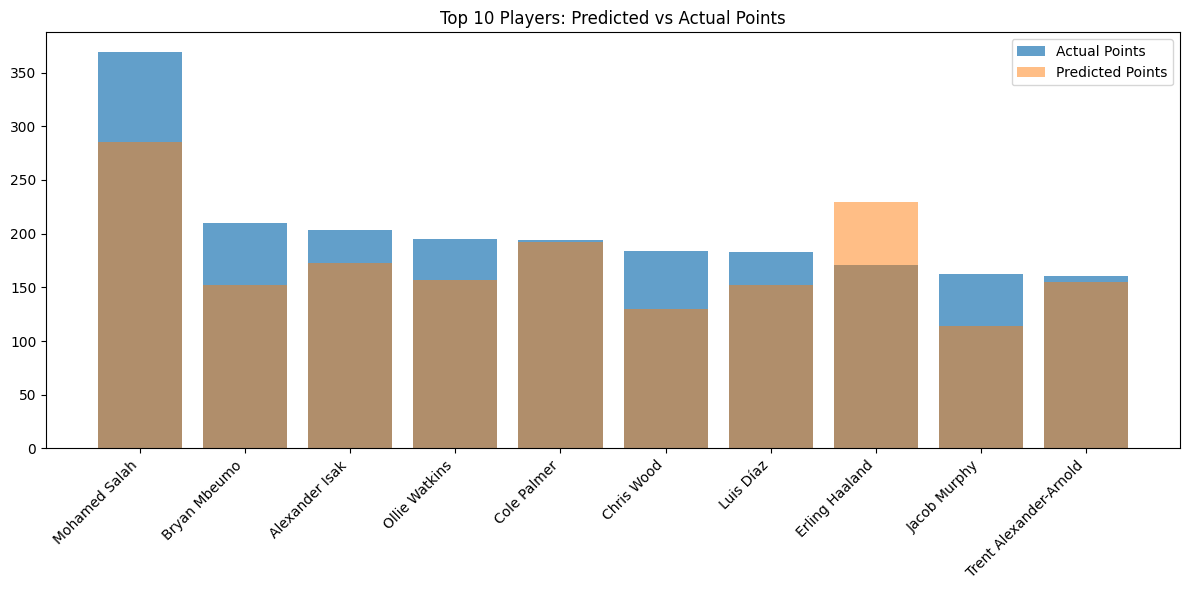


Filtered Dataset Metrics:
MAE: 1.02
RMSE: 1.97


In [43]:
# Basic statistics and visualizations of matched players
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Merge filtered players with their predictions and actual scores
filtered_merged = merged[merged['player_id'].isin(filtered_all_players.index)]

# 2. Calculate per-player performance metrics
player_metrics = filtered_merged.groupby('name').agg({
    'predicted_points': ['mean', 'sum', 'count'],
    'points': ['mean', 'sum'],
    'absolute_error': 'mean',
    'error': ['mean', 'std']
}).round(2)

# Flatten column names
player_metrics.columns = ['_'.join(col).strip() for col in player_metrics.columns]

# Sort by total actual points
player_metrics = player_metrics.sort_values('points_sum', ascending=False)

# Display top 10 players by actual points
print("Top 10 Players by Total Points:")
print(player_metrics.head(10))

# Visualization of prediction accuracy for top players
plt.figure(figsize=(12, 6))
plt.bar(player_metrics.head(10).index, 
        player_metrics.head(10)['points_sum'],
        alpha=0.7,
        label='Actual Points')
plt.bar(player_metrics.head(10).index, 
        player_metrics.head(10)['predicted_points_sum'],
        alpha=0.5,
        label='Predicted Points')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Players: Predicted vs Actual Points')
plt.legend()
plt.tight_layout()
plt.show()

# Calculate prediction accuracy metrics for filtered set
filtered_mae = filtered_merged['absolute_error'].mean()
filtered_rmse = np.sqrt((filtered_merged['error'] ** 2).mean())

print(f"\nFiltered Dataset Metrics:")
print(f"MAE: {filtered_mae:.2f}")
print(f"RMSE: {filtered_rmse:.2f}")

Performance by Position:
         absolute_error       points        predicted_points
                   mean   std   mean  count             mean
position                                                    
DEF                1.03  1.58   1.02   8066             1.06
FWD                1.18  1.95   1.40   2651             1.34
GK                 0.75  1.50   0.90   2545             0.90
MID                1.03  1.74   1.28  10853             1.27


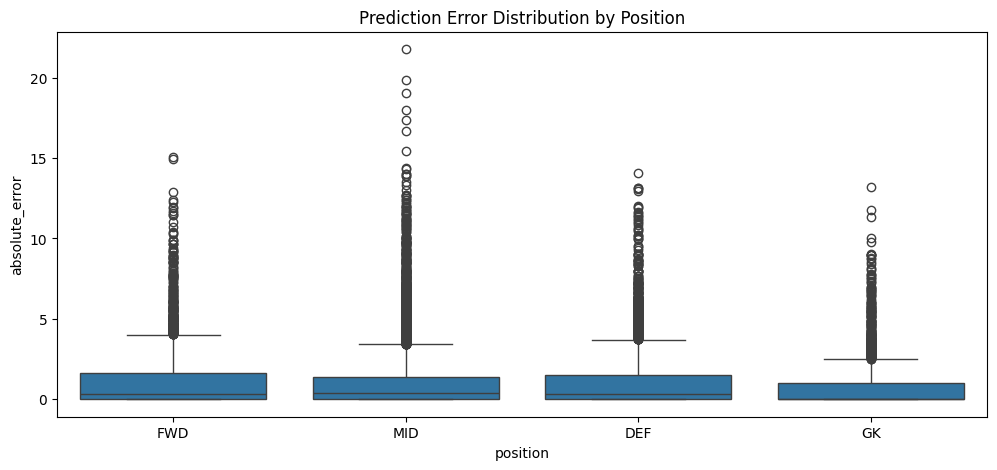


Key Performance Indicators:
Overall MAE: 1.02
Overall RMSE: 1.97
Predictions within 1 point: 68.9%
Predictions within 2 points: 82.7%

Most Consistently Predicted Players:
                           points_mean  predicted_points_mean  \
name                                                            
Wayne Hennessey                    0.0                    0.0   
Spike Brits                        0.0                    0.0   
Stefan Bajčetić Maquieira          0.0                    0.0   
Dermot Mee                         0.0                    0.0   
Jacob Slater                       0.0                    0.0   
Jesurun Rak-Sakyi                  0.0                    0.0   
Jenson Metcalfe                    0.0                    0.0   
Harry Souttar                      0.0                    0.0   
Will Dennis                        0.0                    0.0   
Sean Neave                         0.0                    0.0   

                           absolute_error_mean

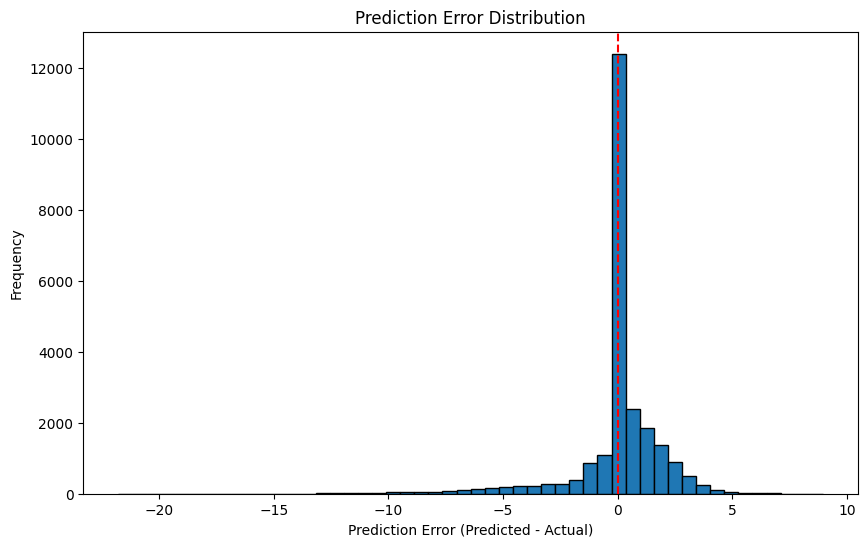

In [44]:
# 1. Performance Analysis by Position
filtered_merged_with_position = filtered_merged.merge(
    fpl_players[['full_name', 'position']], 
    left_on='name', 
    right_on='full_name'
)

position_metrics = filtered_merged_with_position.groupby('position').agg({
    'absolute_error': ['mean', 'std'],
    'points': ['mean', 'count'],
    'predicted_points': 'mean'
}).round(2)

print("Performance by Position:")
print(position_metrics)

# 2. Prediction Accuracy Distribution
plt.figure(figsize=(12, 5))
sns.boxplot(data=filtered_merged_with_position, x='position', y='absolute_error')
plt.title('Prediction Error Distribution by Position')
plt.show()

# 3. Key Performance Indicators
print("\nKey Performance Indicators:")
print(f"Overall MAE: {filtered_mae:.2f}")
print(f"Overall RMSE: {filtered_rmse:.2f}")
print(f"Predictions within 1 point: {(filtered_merged['absolute_error'] <= 1).mean()*100:.1f}%")
print(f"Predictions within 2 points: {(filtered_merged['absolute_error'] <= 2).mean()*100:.1f}%")

# 4. Top Performers Analysis
top_consistent = player_metrics.sort_values('absolute_error_mean').head(10)
print("\nMost Consistently Predicted Players:")
print(top_consistent[['points_mean', 'predicted_points_mean', 'absolute_error_mean']])

# 5. Model Bias Analysis
plt.figure(figsize=(10, 6))
plt.hist(filtered_merged['error'], bins=50, edgecolor='black')
plt.title('Prediction Error Distribution')
plt.xlabel('Prediction Error (Predicted - Actual)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='r', linestyle='--')
plt.show()

/tmp/ipykernel_4919/936240803.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  success_rate_by_position = filtered_merged_with_position.groupby('position').apply(


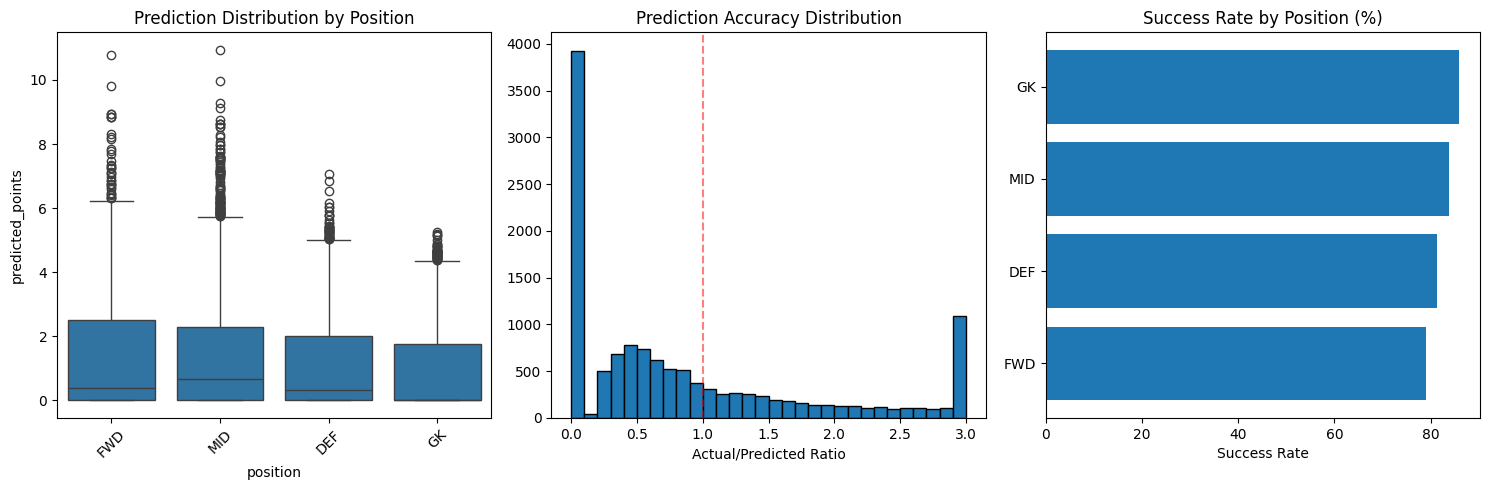


Model Performance Metrics:
--------------------------------------------------
Overall Success Rate: 82.7%
High Score Prediction Rate: 7.4%

Position-wise Performance:
          Success_Rate_%   MAE  Error_Std  Avg_Points  Points_Std  \
position                                                            
DEF                81.29  1.03       1.58        1.02        2.13   
FWD                79.14  1.18       1.95        1.40        2.79   
GK                 85.97  0.75       1.50        0.90        2.07   
MID                83.78  1.03       1.74        1.28        2.42   

          Avg_Predicted  Point_Correlation  
position                                    
DEF                1.06               0.49  
FWD                1.34               0.58  
GK                 0.90               0.59  
MID                1.27               0.55  

Model Stability Score: -47.2%


In [47]:
# Additional Model Strength Analysis with Advanced Metrics
plt.figure(figsize=(15, 5))

# 1. Position-based Performance (Left Plot)
plt.subplot(131)
sns.boxplot(data=filtered_merged_with_position, x='position', y='predicted_points')
plt.title('Prediction Distribution by Position')
plt.xticks(rotation=45)

# 2. Prediction Accuracy (Middle Plot)
plt.subplot(132)
# Filter out zero predictions to avoid division by zero
valid_predictions = filtered_merged[filtered_merged['predicted_points'] > 0]
prediction_ratio = valid_predictions['points'] / valid_predictions['predicted_points']
# Clip ratios to reasonable range for visualization
prediction_ratio = prediction_ratio.clip(0, 3)
plt.hist(prediction_ratio, bins=30, edgecolor='black')
plt.title('Prediction Accuracy Distribution')
plt.xlabel('Actual/Predicted Ratio')
plt.axvline(x=1, color='r', linestyle='--', alpha=0.5)

# 3. Success Rate by Position (Right Plot)
plt.subplot(133)
success_rate_by_position = filtered_merged_with_position.groupby('position').apply(
    lambda x: (x['absolute_error'] <= 2).mean() * 100
).sort_values(ascending=True)

plt.barh(success_rate_by_position.index, success_rate_by_position.values)
plt.title('Success Rate by Position (%)')
plt.xlabel('Success Rate')

plt.tight_layout()
plt.show()

# Print Additional Performance Metrics
print("\nModel Performance Metrics:")
print("-" * 50)
print(f"Overall Success Rate: {(filtered_merged['absolute_error'] <= 2).mean()*100:.1f}%")
print(f"High Score Prediction Rate: {(filtered_merged['points'] >= 6).mean()*100:.1f}%")

# Position-specific Analysis with additional metrics
position_analysis = filtered_merged_with_position.groupby('position').agg({
    'absolute_error': [
        lambda x: (x <= 2).mean() * 100,  # Success rate
        'mean',  # Mean absolute error
        'std'    # Error stability
    ],
    'points': ['mean', 'std'],  # Score patterns
    'predicted_points': [
        'mean',
        lambda x: np.corrcoef(x, filtered_merged_with_position.loc[x.index, 'points'])[0,1]  # Correlation
    ]
}).round(2)

# Rename columns for clarity
position_analysis.columns = [
    'Success_Rate_%', 'MAE', 'Error_Std',
    'Avg_Points', 'Points_Std',
    'Avg_Predicted', 'Point_Correlation'
]

print("\nPosition-wise Performance:")
print(position_analysis)

# Add prediction stability score
stability_score = (1 - position_analysis['Error_Std'].mean() / position_analysis['Avg_Points'].mean()) * 100
print(f"\nModel Stability Score: {stability_score:.1f}%")

In [ ]:
pip install scikit-learn

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(sum_pts[mask]['points'], sum_pts[mask]['predicted_points'])
rmse = mean_squared_error(sum_pts[mask]['points'], sum_pts[mask]['predicted_points'], squared=False)
r2 = r2_score(sum_pts[mask]['points'], sum_pts[mask]['predicted_points'])

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")


In [ ]:
from scipy.stats import zscore

# Calculate Z-scores for the points and predicted_points
sum_pts['z_points'] = zscore(sum_pts['points'])
sum_pts['z_predicted_points'] = zscore(sum_pts['predicted_points'])

# Define outlier threshold (e.g., 3 or -3)
threshold = 3

# Filter rows where Z-score is greater than the threshold (outliers)
outliers = sum_pts[(sum_pts['z_points'].abs() > threshold) | (sum_pts['z_predicted_points'].abs() > threshold)]

print(outliers)



In [ ]:
pip install seaborn

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting boxplot for points and predicted points
plt.figure(figsize=(12, 6))
sns.boxplot(data=[sum_pts['points'], sum_pts['predicted_points']], orient='v')
plt.xticks([0, 1], ['Actual Points', 'Predicted Points'])
plt.title('Boxplot for Points and Predicted Points')
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Scatter plot of predicted vs actual points
plt.scatter(sum_pts['predicted_points'], sum_pts['points'])
plt.xlabel('Predicted Points')
plt.ylabel('Actual Points')
plt.title('Predicted vs Actual Points')
plt.show()

# Plotting residuals (errors)
residuals = sum_pts['points'] - sum_pts['predicted_points']
plt.scatter(sum_pts['predicted_points'], residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Points')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()


In [ ]:
# Filter out rows where actual points are zero to avoid division by zero
sum_pts_non_zero = sum_pts[sum_pts['points'] != 0]

# Calculate MAPE (Mean Absolute Percentage Error)
# Inspect the errors between predicted and actual points
sum_pts_non_zero['error'] = abs(sum_pts_non_zero['points'] - sum_pts_non_zero['predicted_points'])
print(sum_pts_non_zero[['points', 'predicted_points', 'error']].sort_values(by='error', ascending=False).head())




In [ ]:
sum_pts

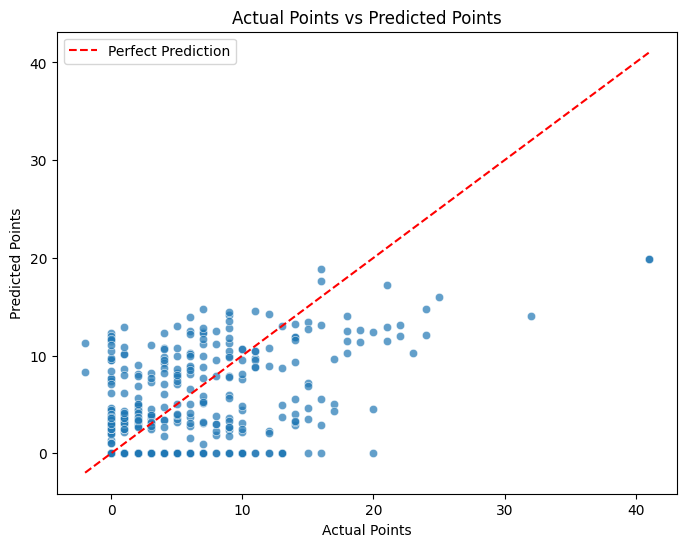

KeyError: 'residuals'

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter Plot: Actual Points vs Predicted Points
plt.figure(figsize=(8, 6))
sns.scatterplot(x=sum_pts['points'], y=sum_pts['predicted_points'], alpha=0.7)
plt.plot([sum_pts['points'].min(), sum_pts['points'].max()], 
         [sum_pts['points'].min(), sum_pts['points'].max()], 
         color='red', linestyle='--', label='Perfect Prediction')
plt.title("Actual Points vs Predicted Points")
plt.xlabel("Actual Points")
plt.ylabel("Predicted Points")
plt.legend()
plt.show()

# Bar Plot: Top 10 Players by Residuals
top_residuals = sum_pts.sort_values('residuals', key=abs, ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_residuals.index, y=top_residuals['residuals'], palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Players by Residuals")
plt.ylabel("Residuals (Actual - Predicted)")
plt.xlabel("Player Name")
plt.show()

# Cumulative Points Comparison
sum_pts['cumulative_points'] = sum_pts['points'].cumsum()
sum_pts['cumulative_predicted'] = sum_pts['predicted_points'].cumsum()
plt.figure(figsize=(10, 6))
plt.plot(sum_pts['cumulative_points'], label='Cumulative Actual Points', marker='o')
plt.plot(sum_pts['cumulative_predicted'], label='Cumulative Predicted Points', marker='o', linestyle='--')
plt.title("Cumulative Points Comparison")
plt.xlabel("Players (Index)")
plt.ylabel("Points")
plt.legend()
plt.show()

# Heatmap: Z-scores of Actual vs Predicted Points
z_scores = sum_pts[['z_points', 'z_predicted_points']]
plt.figure(figsize=(8, 6))
sns.heatmap(z_scores.T, cmap='coolwarm', cbar=True, annot=False, xticklabels=False)
plt.title("Heatmap of Z-scores: Actual vs Predicted Points")
plt.xlabel("Players")
plt.ylabel("Z-scores")
plt.show()
